**BEUST Léna**
________________

# **Word polarity detection with word embedding**

### 1. **Read lexicons**

In [70]:
import re

def read_vocabulary_from_file(filename):
    with open(filename, 'r', encoding="ISO-8859-1") as f:
        content = f.readlines()
    content = [x.strip() for x in content]
    content = [x for x in content if not x.startswith(";") and not x.endswith("+") and x]
    
    # Keep only valid lexicon words: lowercase start, letters and hyphens only
    content = [x for x in content if re.match(r'^[a-z][a-z\-]*$', x)]
    
    return content

In [71]:
positive_words = read_vocabulary_from_file("positive-words.txt")
negative_words = read_vocabulary_from_file("negative-words.txt")

print(positive_words[:5])

# Step 3 — apply filter manually here as a safety net
positive_words = [w for w in positive_words if w[0].islower()]
negative_words = [w for w in negative_words  if w[0].islower()]

['abound', 'abounds', 'abundance', 'abundant', 'accessable']


### 2.**Convert words into vectors**

In [50]:
import numpy as np

In [72]:
# to get GloVe vectors: wget http://nlp.stanford.edu/data/glove.6B.zip
def load_glove_embeddings(path):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f :
            values = line.strip().split()
            w = values[0]
            vectors = np.asarray(values[1:], dtype='float32')
            embeddings[w] = vectors
    return embeddings

In [73]:
# off−line dictionary for glove
word_dict = load_glove_embeddings('glove.6B.50d.txt')
word = 'happy'
vector = word_dict[word]

In [ ]:
pos_in_glove = [w for w in positive_words if w in word_dict]
neg_in_glove  = [w for w in negative_words  if w in word_dict]

### 3.**Prepare the training and testing sets**

In [78]:
embedding_dim = 50
n_train = 1500
n_test  = 500

pos_train = pos_in_glove[:n_train]    # first 1500
neg_train = neg_in_glove[:n_train]    # first 1500

X_train = np.zeros((n_train * 2, embedding_dim), dtype=float)
Y_train = np.zeros((n_train * 2, 2),             dtype=float)

for i, word in enumerate(pos_train):
    X_train[i] = word_dict[word]
    Y_train[i] = [1.0, 0.0]                      # positive label

for i, word in enumerate(neg_train):
    X_train[n_train + i] = word_dict[word]
    Y_train[n_train + i] = [0.0, 1.0]            # negative label

pos_test = pos_in_glove[n_train : n_train + n_test]
neg_test = neg_in_glove[n_train : n_train + n_test]

X_test = np.zeros((n_test * 2, embedding_dim), dtype=float)
Y_test = np.zeros((n_test * 2, 2),             dtype=float)

for i, word in enumerate(pos_test):
    X_test[i] = word_dict[word]
    Y_test[i] = [1.0, 0.0]

for i, word in enumerate(neg_test):
    X_test[n_test + i] = word_dict[word]
    Y_test[n_test + i] = [0.0, 1.0]

print("X_train shape:", X_train.shape)  # (3000, 50)
print("Y_train shape:", Y_train.shape)  # (3000, 2)
print("X_test shape: ", X_test.shape)   # (1000, 50)
print("Y_test shape: ", Y_test.shape)   # (1000, 2)

X_train shape: (3000, 50)
Y_train shape: (3000, 2)
X_test shape:  (1000, 50)
Y_test shape:  (1000, 2)


### 4. **Train and evaluate a classifier**

In [79]:
import tensorflow as tf

2026-05-09 11:34:31.184331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-09 11:34:31.269723: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-09 11:34:31.270056: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-09 11:34:31.394636: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 11:34:32.535332: W tensorflow/compiler/tf

In [90]:
import matplotlib.pyplot as plt

model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(embedding_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),       # smaller than before
    tf.keras.layers.Dropout(0.5),                       # stronger dropout
    tf.keras.layers.Dense(32, activation='relu'),       # smaller than before
    tf.keras.layers.Dropout(0.5),                       # stronger dropout
    tf.keras.layers.Dense(2, activation='softmax'),
])

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,410 (21.13 KB)

 Trainable params: 5,410 (21.13 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',   # surveille l'accuracy test plutôt que la loss
    patience=10,              # arrête après 10 epochs sans amélioration
    min_delta=0.001,          # une amélioration de moins de 0.1% compte comme stagnation
    restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    epochs=100,                        # let early stopping decide when to stop
    batch_size=64,                     # larger batch = more stable gradients
    validation_data=(X_test, Y_test),
    callbacks=[early_stop],
    verbose=1
)

train_loss, train_acc = model.evaluate(X_train, Y_train, verbose=0)
test_loss,  test_acc  = model.evaluate(X_test,  Y_test,  verbose=0)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9140 - loss: 0.2162 - val_accuracy: 0.7500 - val_loss: 0.3816
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9150 - loss: 0.2141 - val_accuracy: 0.7510 - val_loss: 0.3821
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9200 - loss: 0.2057 - val_accuracy: 0.7480 - val_loss: 0.3802
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9143 - loss: 0.2146 - val_accuracy: 0.7520 - val_loss: 0.3810
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9187 - loss: 0.2063 - val_accuracy: 0.7540 - val_loss: 0.3823
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9143 - loss: 0.2161 - val_accuracy: 0.7510 - val_loss: 0.3865
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9187 - loss: 0.2007 - val_accuracy: 0.7520 - val_loss: 0.3886
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9157 - loss: 0.2122 - val_accuracy: 0.7530 - v

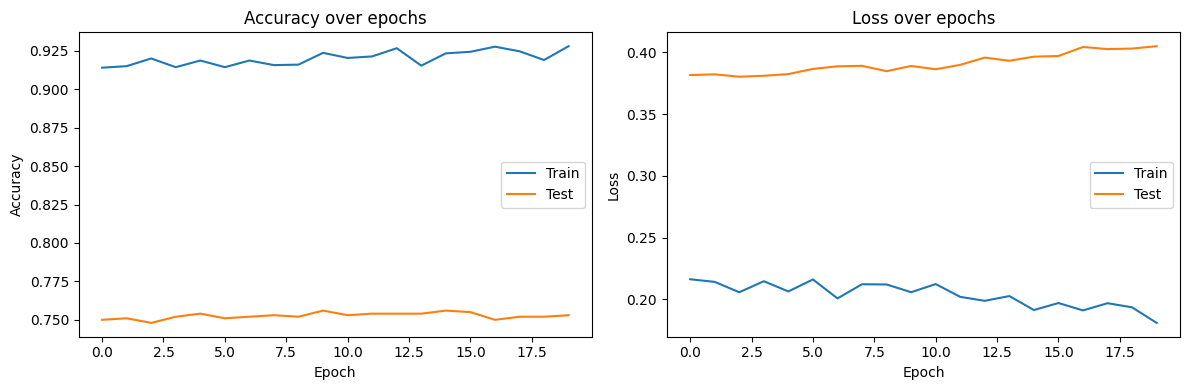

In [96]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Test')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Test')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

The final train accuracy id 98% while test accuracy is 74%. The performances are good beacause the GloVe embeddings do most of the heavy lifting — the MLP only needs to learn a linear-ish boundary in the 50-dimensional embedding space. There is a clearly overfitting despite early stopping  and dropout.

### 5. **Analysis of results and discussions**

In [97]:
def predict_word(word):
    if word not in word_dict:
        return None
    vec = word_dict[word]
    x = np.array([vec])  # shape (1, 50)
    probs = model.predict(x, verbose=0)[0]
    label = "POSITIVE" if probs[0] > probs[1] else "NEGATIVE"
    return probs[0], probs[1], label

def report_words(words, title):
    print(f"\n{'─'*55}")
    print(f" {title}")
    print(f"{'─'*55}")
    print(f"{'Word':<20} {'P(pos)':>8} {'P(neg)':>8}  {'Label'}")
    print(f"{'─'*55}")
    for word in words:
        result = predict_word(word)
        if result is None:
            print(f"{word:<20} {'(not in GloVe)':>20}")
        else:
            p_pos, p_neg, label = result
            print(f"{word:<20} {p_pos:>8.3f} {p_neg:>8.3f}  {label}")



In [99]:
clear_positive = [
    "sunshine", "paradise", "breathtaking",
    "triumph", "radiant", "flourish"
]

report_words(clear_positive, "Clearly POSITIVE words")


───────────────────────────────────────────────────────
 Clearly POSITIVE words
───────────────────────────────────────────────────────
Word                   P(pos)   P(neg)  Label
───────────────────────────────────────────────────────
sunshine                1.000    0.000  POSITIVE
paradise                0.986    0.014  POSITIVE
breathtaking            0.996    0.004  POSITIVE
triumph                 1.000    0.000  POSITIVE
radiant                 1.000    0.000  POSITIVE
flourish                0.986    0.014  POSITIVE


In [100]:
# Clearly negative (model should be confident)
clear_negative = [
    "catastrophe", "miserable", "devastating",
    "horrible", "worthless"
]

report_words(clear_negative, "Clearly NEGATIVE words")


───────────────────────────────────────────────────────
 Clearly NEGATIVE words
───────────────────────────────────────────────────────
Word                   P(pos)   P(neg)  Label
───────────────────────────────────────────────────────
catastrophe             0.001    0.999  NEGATIVE
miserable               0.020    0.980  NEGATIVE
devastating             0.000    1.000  NEGATIVE
horrible                0.002    0.998  NEGATIVE
worthless               0.128    0.872  NEGATIVE


In [101]:
# Hesitant words — ambiguous or context-dependent
hesitant_words = [
    "surprising", "powerful", "cheap",
    "simple", "bold", "loud", "raw"
]

report_words(hesitant_words, "Hesitant words [0.4 - 0.6]")


───────────────────────────────────────────────────────
 Hesitant words [0.4 - 0.6]
───────────────────────────────────────────────────────
Word                   P(pos)   P(neg)  Label
───────────────────────────────────────────────────────
surprising              0.894    0.106  POSITIVE
powerful                0.696    0.304  POSITIVE
cheap                   0.461    0.539  NEGATIVE
simple                  1.000    0.000  POSITIVE
bold                    0.989    0.011  POSITIVE
loud                    0.055    0.945  NEGATIVE
raw                     0.900    0.100  POSITIVE


It's hard to categorize ambigous words without the context like 'raw' or 'cheap' : it could be good or bad whether the context. The model has very good results with positiv and negativ word that he never saw before.

### 6. **Extension to sentences**
What would be the limitations of such system and how could we improve it ? What is happening when a word is not in the dictionary of the embedding ?


1. Out-of-vocabulary (OOV) words : Any word not in GloVe is simply skipped — the system cannot make any prediction. 

2. Word-level only, no context : The system classifies isolated words, not sentences.

3. Static embeddings : GloVe vectors are frozen — they never adapt to your task or domain.

4. Training data bias : The lexicon itself is biased toward formal English. 

5. Binary classification only : Sentiment is reduced to positive/negative with no notion of intensity ("good" vs "extraordinary") or neutrality.